# Imports e Configuração

In [ ]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam
from metrics import accuracy

from utils import (
  NumpyTfidfVectorizer,
  NumpyDataset,
  train_test_split_stratified,
  one_hot_encode,
  accuracy_score_np,
  classification_report_np,
  confusion_matrix_np,
  prepare_label_arrays,
  build_vectorized_datasets,
  balanced_accuracy_from_preds,
  apply_human_confidence_rule,
  tune_human_threshold,
)

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# 1. Carregamento e Preparação dos Dados

In [2]:
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

df_teste = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_teste = df_teste.dropna(subset=['Text', 'Label'])

print("Distribuição do dataset de treino:")
print(df['Label'].value_counts())
print(f"\nTotal: {len(df)} amostras")

print("\nDistribuição do dataset de teste:")
print(df_teste['Label'].value_counts())
print(f"Total: {len(df_teste)} amostras")

Distribuição do dataset de treino:
Label
Human        999
OpenAI       999
Google       999
Meta         999
Anthropic    999
Name: count, dtype: int64

Total: 4995 amostras

Distribuição do dataset de teste:
Label
Human        52
Anthropic    23
Meta         17
OpenAI       17
Google       16
Name: count, dtype: int64
Total: 125 amostras


In [3]:
X = df['Text'].values
y = df['Label'].values

X_teste = df_teste['Text'].values
y_teste = df_teste['Label'].values

X_train, X_val, y_train, y_val = train_test_split_stratified(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Modelo de Regressão Logística de Baseline

In [4]:
label_data = prepare_label_arrays(y_train, y_val, y_teste)
labels = label_data['labels']
class_to_idx = label_data['class_to_idx']
human_idx = label_data['human_idx']
y_train_oh = label_data['y_train_oh']
y_val_oh = label_data['y_val_oh']
y_teste_oh = label_data['y_test_oh']

baseline_data = build_vectorized_datasets(
    X_train,
    X_val,
    X_teste,
    y_train_oh,
    y_val_oh,
    y_teste_oh,
    vectorizer_params={
        'max_features': 3000,
        'ngram_range': (1, 2),
        'stop_words': 'english',
    },
)

vectorizer = baseline_data['vectorizer']
X_train_vec = baseline_data['X_train_vec']
X_val_vec = baseline_data['X_val_vec']
X_teste_vec = baseline_data['X_test_vec']

train_ds = baseline_data['train_ds']
val_ds = baseline_data['val_ds']
test_ds = baseline_data['test_ds']

baseline = NeuralNetwork(
    epochs=200,
    batch_size=64,
    optimizer=Adam(learning_rate=0.01),
    verbose=True,
    loss=CategoricalCrossEntropy,
    metric=accuracy,
    patience=15,
)
baseline.add(DenseLayer(n_units=len(labels), input_shape=(X_train_vec.shape[1],), init_type='xavier'))
baseline.add(SoftmaxActivation())

baseline.fit(train_ds, val_dataset=val_ds, patience=15)

val_probs = baseline.predict(val_ds)
test_probs = baseline.predict(test_ds)

raw_val_preds = np.array([labels[i] for i in np.argmax(val_probs, axis=1)])
raw_test_preds = np.array([labels[i] for i in np.argmax(test_probs, axis=1)])

baseline_best_threshold, baseline_best_bal_acc, baseline_best_acc = tune_human_threshold(
    val_probs,
    y_val,
    labels,
    human_idx,
)

val_preds = apply_human_confidence_rule(val_probs, labels, human_idx, baseline_best_threshold)
test_preds = apply_human_confidence_rule(test_probs, labels, human_idx, baseline_best_threshold)

baseline_val_acc_raw = accuracy_score_np(y_val, raw_val_preds)
baseline_val_acc_adj = accuracy_score_np(y_val, val_preds)
baseline_test_acc_raw = accuracy_score_np(y_teste, raw_test_preds)
baseline_test_acc_adj = accuracy_score_np(y_teste, test_preds)

Epoch 1/200 - loss: 1.3681 - val_loss: 1.1669 - accuracy: 0.5840
Epoch 10/200 - loss: 0.2565 - val_loss: 0.5051 - accuracy: 0.9850
Epoch 20/200 - loss: 0.1103 - val_loss: 0.4261 - accuracy: 0.9997
Epoch 30/200 - loss: 0.0604 - val_loss: 0.4102 - accuracy: 1.0000
Epoch 40/200 - loss: 0.0371 - val_loss: 0.4094 - accuracy: 1.0000
Epoch 50/200 - loss: 0.0244 - val_loss: 0.4150 - accuracy: 1.0000

[Early Stopping] Parou na época 51. Melhor Val Loss: 0.4085


## Análise de Métricas e Resultados

Best Human confidence threshold (val): 0.40
Validation balanced accuracy (adjusted): 0.8470
Validation accuracy raw -> adjusted: 0.8470 -> 0.8470
Test accuracy raw -> adjusted: 0.5680 -> 0.5680

Classification report (teste) - Baseline adjusted:
class          precision    recall  f1-score   support
Anthropic         0.6667    0.0870    0.1538        23
Google            0.4375    0.4375    0.4375        16
Human             0.6528    0.9038    0.7581        52
Meta              0.5000    0.6471    0.5641        17
OpenAI            0.3333    0.2353    0.2759        17

macro avg         0.5181    0.4621    0.4379       125
weighted avg      0.5636    0.5680    0.5139       125


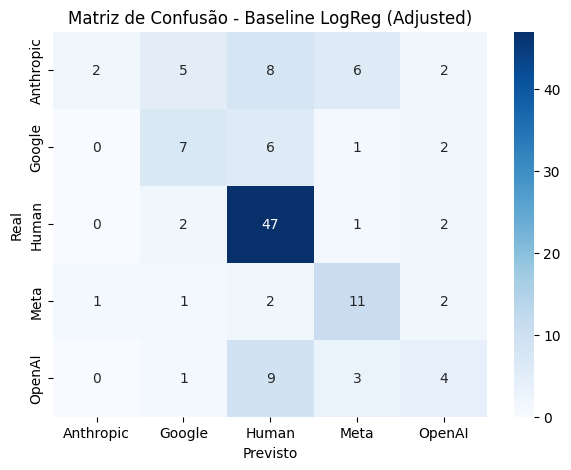

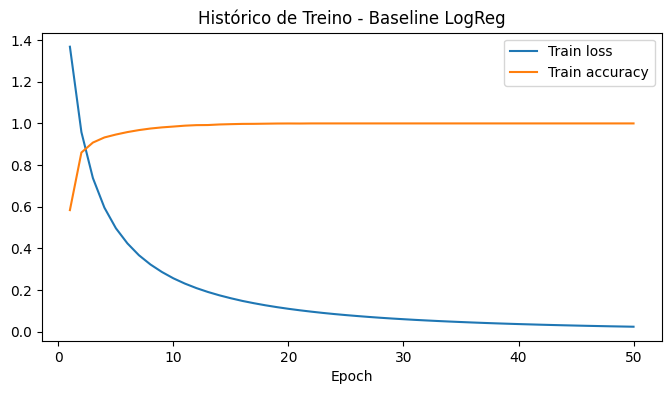

In [5]:
print(f'Best Human confidence threshold (val): {baseline_best_threshold:.2f}')
print(f'Validation balanced accuracy (adjusted): {baseline_best_bal_acc:.4f}')
print(f'Validation accuracy raw -> adjusted: {baseline_val_acc_raw:.4f} -> {baseline_val_acc_adj:.4f}')
print(f'Test accuracy raw -> adjusted: {baseline_test_acc_raw:.4f} -> {baseline_test_acc_adj:.4f}')
print('\nClassification report (teste) - Baseline adjusted:')
print(classification_report_np(y_teste, test_preds, labels))

cm = confusion_matrix_np(y_teste, test_preds, labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Baseline LogReg (Adjusted)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

history_df = pd.DataFrame.from_dict(baseline.history, orient='index')
plt.figure(figsize=(8, 4))
plt.plot(history_df.index, history_df['loss'], label='Train loss')
plt.plot(history_df.index, history_df['metric'], label='Train accuracy')
plt.title('Histórico de Treino - Baseline LogReg')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Modelo de Rede Neural Densa (DNN)

In [6]:
label_data_dnn = prepare_label_arrays(y_train, y_val, y_teste)
labels = label_data_dnn['labels']
class_to_idx_dnn = label_data_dnn['class_to_idx']
n_classes = label_data_dnn['n_classes']
human_idx = label_data_dnn['human_idx']
y_train_idx_dnn = label_data_dnn['y_train_idx']
y_train_oh_dnn = label_data_dnn['y_train_oh']
y_val_oh_dnn = label_data_dnn['y_val_oh']
y_teste_oh_dnn = label_data_dnn['y_test_oh']

dnn_data = build_vectorized_datasets(
    X_train,
    X_val,
    X_teste,
    y_train_oh_dnn,
    y_val_oh_dnn,
    y_teste_oh_dnn,
    vectorizer_params={
        'max_features': 8000,
        'analyzer': 'char',
        'ngram_range': (3, 5),
    },
)

vectorizer_dnn = dnn_data['vectorizer']
X_train_vec_dnn = dnn_data['X_train_vec']
X_val_vec_dnn = dnn_data['X_val_vec']
X_teste_vec_dnn = dnn_data['X_test_vec']

train_ds_dnn = dnn_data['train_ds']
val_ds_dnn = dnn_data['val_ds']
test_ds_dnn = dnn_data['test_ds']

class_counts = np.bincount(y_train_idx_dnn, minlength=n_classes)
class_weights = len(y_train_idx_dnn) / (n_classes * np.maximum(class_counts, 1))
print('Class weights:', {labels[i]: round(class_weights[i], 4) for i in range(n_classes)})

dnn = NeuralNetwork(
    epochs=250,
    batch_size=64,
    optimizer=Adam(learning_rate=0.001),
    verbose=True,
    loss=CategoricalCrossEntropy(class_weights=class_weights),
    metric=accuracy,
    patience=20,
)

input_dim = X_train_vec_dnn.shape[1]

dnn.add(DenseLayer(n_units=512, input_shape=(input_dim,), init_type='he'))
dnn.add(ReLUActivation())
dnn.add(DropoutLayer(dropout_rate=0.3))

dnn.add(DenseLayer(n_units=256, init_type='he'))
dnn.add(ReLUActivation())
dnn.add(DropoutLayer(dropout_rate=0.3))

dnn.add(DenseLayer(n_units=128, init_type='he'))
dnn.add(ReLUActivation())
dnn.add(DropoutLayer(dropout_rate=0.2))

dnn.add(DenseLayer(n_units=n_classes, init_type='xavier'))
dnn.add(SoftmaxActivation())

dnn.fit(train_ds_dnn, val_dataset=val_ds_dnn, patience=20)

val_probs_dnn = dnn.predict(val_ds_dnn)
test_probs_dnn = dnn.predict(test_ds_dnn)

raw_val_preds_dnn = np.array([labels[i] for i in np.argmax(val_probs_dnn, axis=1)])
raw_test_preds_dnn = np.array([labels[i] for i in np.argmax(test_probs_dnn, axis=1)])

Class weights: {'Anthropic': np.float64(1.0), 'Google': np.float64(1.0), 'Human': np.float64(1.0), 'Meta': np.float64(1.0), 'OpenAI': np.float64(1.0)}
Epoch 1/250 - loss: 0.9810 - val_loss: 0.4301 - accuracy: 0.6120
Epoch 10/250 - loss: 0.0128 - val_loss: 0.6159 - accuracy: 0.9952
Epoch 20/250 - loss: 0.0149 - val_loss: 0.6189 - accuracy: 0.9962

[Early Stopping] Parou na época 22. Melhor Val Loss: 0.3220


## Análise de Métricas e Resultados

Best Human confidence threshold (val): 0.60
Validation balanced accuracy (adjusted): 0.8630
Validation accuracy raw -> adjusted: 0.8580 -> 0.8630
Test accuracy raw -> adjusted: 0.6320 -> 0.6480

Classification report (teste) - DNN adjusted:
class          precision    recall  f1-score   support
Anthropic         0.8462    0.4783    0.6111        23
Google            0.6154    0.5000    0.5517        16
Human             0.6533    0.9423    0.7717        52
Meta              0.5263    0.5882    0.5556        17
OpenAI            0.6000    0.1765    0.2727        17

macro avg         0.6482    0.5371    0.5526       125
weighted avg      0.6594    0.6480    0.6167       125


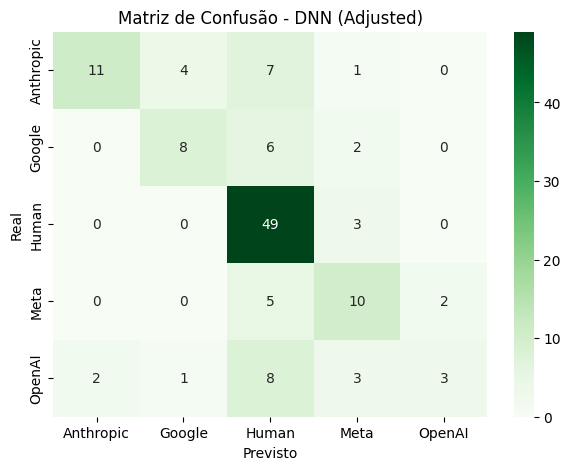

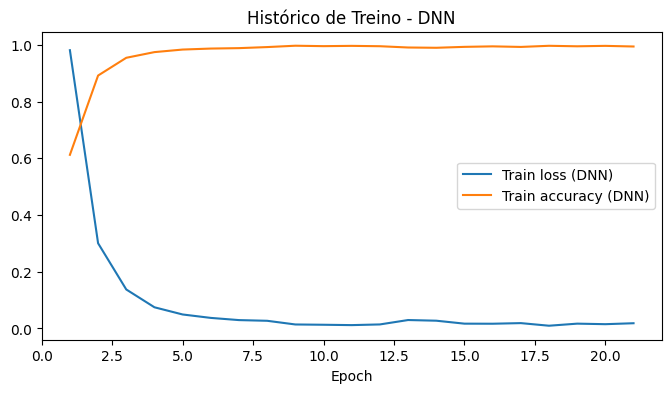

In [7]:
dnn_best_threshold, dnn_best_bal_acc, dnn_best_acc = tune_human_threshold(
    val_probs_dnn,
    y_val,
    labels,
    human_idx,
)

val_preds_dnn = apply_human_confidence_rule(val_probs_dnn, labels, human_idx, dnn_best_threshold)
test_preds_dnn = apply_human_confidence_rule(test_probs_dnn, labels, human_idx, dnn_best_threshold)

dnn_val_acc_raw = accuracy_score_np(y_val, raw_val_preds_dnn)
dnn_val_acc_adj = accuracy_score_np(y_val, val_preds_dnn)
dnn_test_acc_raw = accuracy_score_np(y_teste, raw_test_preds_dnn)
dnn_test_acc_adj = accuracy_score_np(y_teste, test_preds_dnn)

print(f'Best Human confidence threshold (val): {dnn_best_threshold:.2f}')
print(f'Validation balanced accuracy (adjusted): {dnn_best_bal_acc:.4f}')
print(f'Validation accuracy raw -> adjusted: {dnn_val_acc_raw:.4f} -> {dnn_val_acc_adj:.4f}')
print(f'Test accuracy raw -> adjusted: {dnn_test_acc_raw:.4f} -> {dnn_test_acc_adj:.4f}')
print('\nClassification report (teste) - DNN adjusted:')
print(classification_report_np(y_teste, test_preds_dnn, labels))

cm_dnn = confusion_matrix_np(y_teste, test_preds_dnn, labels)
cm_dnn_df = pd.DataFrame(cm_dnn, index=labels, columns=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_dnn_df, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - DNN (Adjusted)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

history_dnn_df = pd.DataFrame.from_dict(dnn.history, orient='index')
plt.figure(figsize=(8, 4))
plt.plot(history_dnn_df.index, history_dnn_df['loss'], label='Train loss (DNN)')
plt.plot(history_dnn_df.index, history_dnn_df['metric'], label='Train accuracy (DNN)')
plt.title('Histórico de Treino - DNN')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## Comparação Final: Baseline vs DNN (Raw vs Adjusted)

Resumo comparativo:


,Model,Val Accuracy (Raw),Val Accuracy (Adjusted),Test Accuracy (Raw),Test Accuracy (Adjusted),Best Human Threshold,Val Balanced Accuracy (Adjusted)
0,Baseline LogReg,0.847,0.847,0.568,0.568,0.4,0.847
1,DNN,0.858,0.863,0.632,0.648,0.6,0.863


<Figure size 800x400 with 0 Axes>

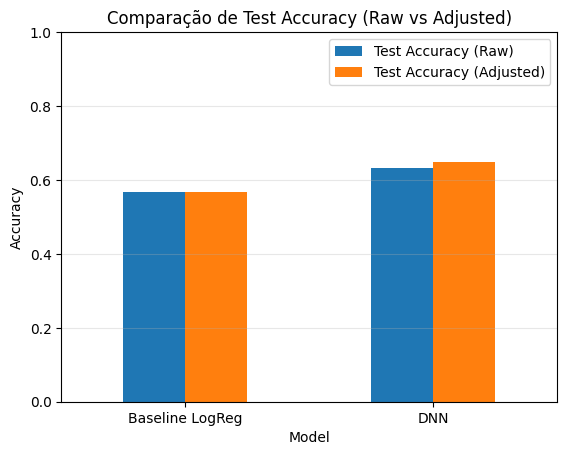

In [8]:
comparison_df = pd.DataFrame(
    [
        {
            'Model': 'Baseline LogReg',
            'Val Accuracy (Raw)': baseline_val_acc_raw,
            'Val Accuracy (Adjusted)': baseline_val_acc_adj,
            'Test Accuracy (Raw)': baseline_test_acc_raw,
            'Test Accuracy (Adjusted)': baseline_test_acc_adj,
            'Best Human Threshold': baseline_best_threshold,
            'Val Balanced Accuracy (Adjusted)': baseline_best_bal_acc,
        },
        {
            'Model': 'DNN',
            'Val Accuracy (Raw)': dnn_val_acc_raw,
            'Val Accuracy (Adjusted)': dnn_val_acc_adj,
            'Test Accuracy (Raw)': dnn_test_acc_raw,
            'Test Accuracy (Adjusted)': dnn_test_acc_adj,
            'Best Human Threshold': dnn_best_threshold,
            'Val Balanced Accuracy (Adjusted)': dnn_best_bal_acc,
        },
    ]
)

numeric_cols = [
    'Val Accuracy (Raw)',
    'Val Accuracy (Adjusted)',
    'Test Accuracy (Raw)',
    'Test Accuracy (Adjusted)',
    'Best Human Threshold',
    'Val Balanced Accuracy (Adjusted)',
]
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

print('Resumo comparativo:')
display(comparison_df)

plt.figure(figsize=(8, 4))
plot_df = comparison_df.set_index('Model')[['Test Accuracy (Raw)', 'Test Accuracy (Adjusted)']]
plot_df.plot(kind='bar', rot=0)
plt.title('Comparação de Test Accuracy (Raw vs Adjusted)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()